In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import cvxpy as cp
import statsmodels.api as sm
import missingno as msno
from pandas_datareader import data as pdr
from scipy.linalg import sqrtm


In [19]:
start = "2015-01-01"
end = "2026-01-01"

tickers = [
    "VTI",  # Vanguard Total Stock Market (Mercado total EE.UU.)
    "QQQ",  # Invesco QQQ Trust (Tecnología Nasdaq 100)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "ASML",  # ASML Holding (Semiconductores, ciclo de innovación)
    "XWD.TO",  # iShares MSCI World ETF (Renta variable global)
    "GLD",  # SPDR Gold Shares  (Oro, refugio de valor)
    "USO",  # United States Oil Fund, LP (Petróleo, energía)
    "AGZD",  # WisdomTree Interest Rate Hedged U.S. Aggregate Bond Fund (Cobertura de tipos)
    "DBA",  # Invesco DB Agriculture Fund (Materias primas agrícolas)
    "VNQ",  # Vanguard Real Estate Index Fund ETF Shares (Bienes raíces)
    "SH",  # ProShares Short S&P500 (Inverso del mercado)
    "VXX",  # iPath Series B S&P 500 VIX Short-Term Futures ETN (Volatilidad/Miedo)
    "TLT",  # iShares 20+ Year Treasury Bond ETF (Bonos largo plazo)
    "PSQ",
        "BA",
    "BAX",
    "BMY",
    "CMCSA",
    "CNP",
    "CPB",
    "DE",
    "F",
    "GE",
    "HPQ",
    "JCI",
    "JPM",
    "KHC",
    "LUV",
    "MMC",
    "MO",
    "NI",
    "PCAR",
    "PSA",
    "SEE",
    "T",
    "TGT",
    "TMO",
    "TXT",
    "VZ",
    "ZION",
# ProShares Short QQQ (Inverso de tecnología)
]

data = yf.download(tickers, start, end, multi_level_index= False)["Close"]
data_idx = yf.download("SPY", start,end, multi_level_index=False)["Close"]

/tmp/ipykernel_1287/3557852571.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start, end, multi_level_index= False)["Close"]
[*********************100%***********************]  40 of 40 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MMC']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_1287/3557852571.py:49: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_idx = yf.download("SPY", start,end, multi_level_index=False)["Close"]
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Forma alternativa csv

df = pd.read_excel("mi_archivo.xlsx / .csv", index_col = 0, delimeter = "el que sea", parse_dta = True)

activos = [
    "ES0160994002",
    "IE00B42W3S00",
    "IE00BZ4D7648",
    "IE000U9ODG19",
    "LU0261948904",
    "LU0996179007",
    "LU1213836080",
]
# Carpeta donde se encuentran los ficheros.
root_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/refs/heads/Feb-2025/Tema_2_Carteras_Intro/data/"
# Creamos una lista para almacenar todos los DF.
df_list = []
# Leemos los ficheros y creamos los DF.
for file_name in activos:
    df = pd.read_csv(root_path + file_name + ".csv", delimiter=";")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
    df_list.append(df)
# Combinamos todos los DF en uno solo.
data = pd.concat(df_list, axis=1)
# Renombramos las columnas.
data.columns = activos



In [27]:
msno.matrix(data_idx)

IndexError: tuple index out of range

In [23]:
data = data.dropna(axis = 1, how = "all")
data = data.dropna(axis = 0, how = "any")


<Axes: >

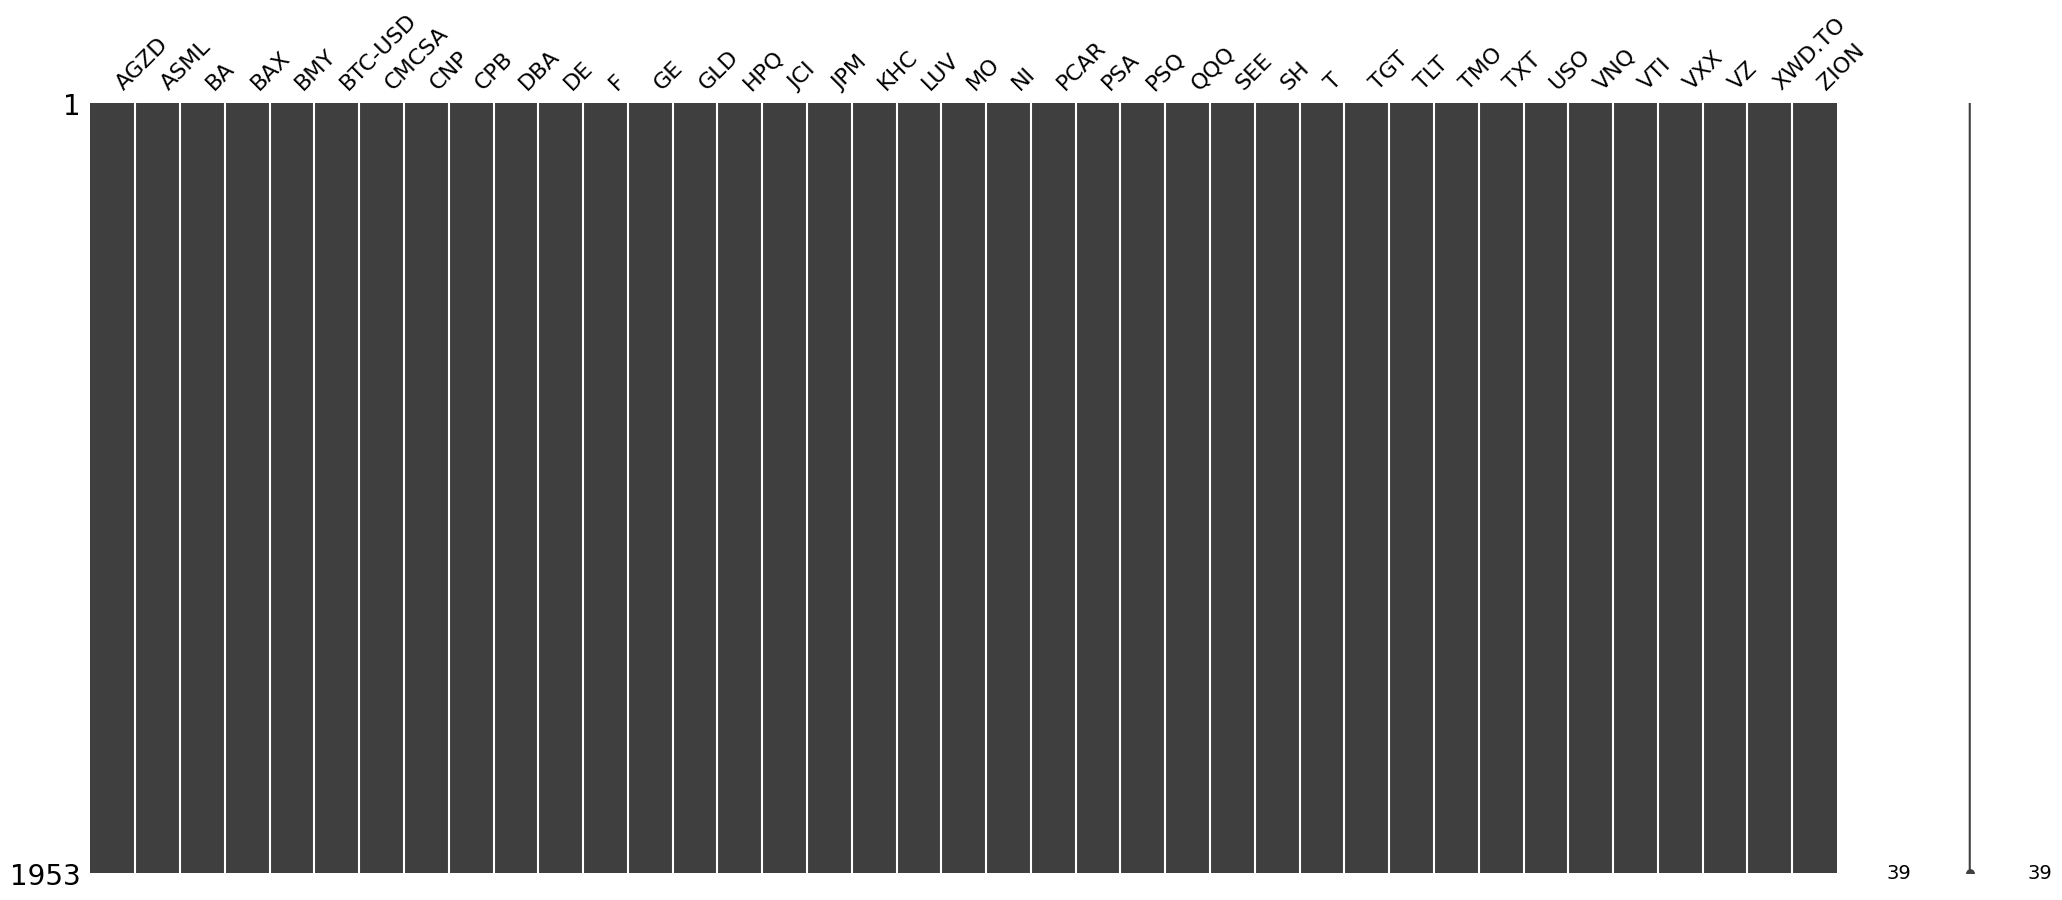

In [24]:
msno.matrix(data)

In [30]:
ret_data = np.log(data).diff().dropna()
ret_idx = np.log(data).diff().dropna()

In [ ]:
def cartera_min_vol(ret, num_activos):
    """Función que calcula la cartera de mínima varianza para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínima varianza"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        num_act = num_activos
        matriz_cov = ret.cov().to_numpy()

        # Variables de decisión
        pesos = cp.Variable(num_act)

        # Restricciones
        constraints = [
            pesos >= 0,
            cp.sum(pesos) == 1,
        ]

        riesgo = cp.quad_form(pesos, matriz_cov)  # Riesgo de la cartera
        objective = cp.Minimize(riesgo)  # Minimizar la varianza

        # Problema y resuelvo
        prob = cp.Problem(objective, constraints)
        resultado = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError(
            "La función cartera_min_vol solo acepta un DataFrame como argumento"
        )  # Si el argumento no es un DataFrame, lanzo un error



In [ ]:
def cartera_max_sharpe(ret, ret_rf, num_activos):
    """Función que calcula la cartera de máximo índice de Sharpe para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    ret_rf: Rendimiento del activo libre de riesgo
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo índice de Sharpe"""

    if isinstance(ret, pd.DataFrame):
        num_act = num_activos
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean()

        # Variable de decisión (pesos del portafolio)
        x = cp.Variable(num_act)
        # Riesgo (desviación estándar) del portafolio
        riesgo = cp.quad_form(x, matriz_cov)

        # Cálculo de pi como retornos esperados menos la rantabilidad del activo libre de riesgo
        pi = np.array(retornos_esperados - ret_rf)

        # Restricciones
        constraints = [
            pi @ x == 1,  # para que el numerador sea 1
            x >= 0,
        ]  # sin posiciones cortas

        objective = cp.Minimize(riesgo)  # Minimizo el riesgo

        # Problema de optimización
        problema = cp.Problem(objective, constraints)

        # Resolver el problema
        resultado = problema.solve()

        # Normalizo los pesos
        pesos = x.value
        pesos /= pesos.sum()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0 for x in pesos])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_max_sharpe solo acepta un DataFrame como argumento")

In [ ]:
def cartera_risk_parity(ret, num_activos):
    """
    Función que calcula la cartera de riesgo paridad para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de riesgo paridad"""

    if isinstance(ret, pd.DataFrame):
        num_act = num_activos
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        b = 1 / num_act

        x = cp.Variable(num_act)
        gamma = cp.Variable(num_act, nonneg=True)
        psi = cp.Variable(nonneg=True)

        z = matriz_cov @ x

        obj = cp.pnorm(b**0.5 * psi - gamma, p=2)
        ret = retornos_esperados.T @ x

        constraints = [cp.sum(x) == 1, x >= 0, cp.SOC(psi, sqrtm(matriz_cov) @ x)]

        for i in range(num_act):
            constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

        objective = cp.Minimize(obj * 1000)
        prob = cp.Problem(objective, constraints)
        prob.solve()

        pesos_ajustados = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_risk_parity solo acepta un DataFrame como argumento")

In [ ]:
def cartera_min_cvar(ret, num_activos):

  if isinstance(ret,pd.DataFrame):

    num_act = num_activos
    num_data = ret.shape[0]
    alpha = 0.05
    retornos_esperados = ret.mean().to_numpy()

    pesos = cp.Variable(num_act)
    t = cp.Variable()
    ui = cp.Variable(num_data)

    riesgo = t + cp.sum(ui) / (alpha * num_data)
    retornos = retornos_esperados.T @ pesos

    restricciones = [-ret @ pesos - t- ui <= 0,
                     ui >= 0,
                     cp.sum(pesos) == 1,
                     pesos >= 0]

    objective = cp.Minimize(riesgo)

    prob = cp.Problem(objective, restricciones)
    cvar95_min_cvar = prob.solve()

    pesos_ajustados_cvar = np.array([np.round(x, 3) if x > 10**-4 else 0  for x in pesos.value])

    return pesos_ajustados_cvar

  else:
    return None

In [ ]:
def cartera_max_drawdown(ret, alpha=0.5):

    ''' Función que calcula la cartera de máximo drawdown para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    alpha: Nivel de confianza
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo drawdown'''

    if isinstance(ret, pd.DataFrame): # Verifico que el argumento sea un DataFrame
        retornos = ret.to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        num_data, num_act = retornos.shape # Número de datos y número de activos

        pesos = cp.Variable(num_act)
        t = cp.Variable()
        uj = cp.Variable(num_data)
        dj = cp.Variable(num_data+1)

        riesgo = t + cp.sum(uj)/(alpha * num_data)
        #retornos_cartera = retornos_esperados.T @ pesos

        restricciones = [dj[1:] - t - uj <= 0,
                        dj[1:] >= dj[:-1] - retornos @ pesos,
                        uj >= 0,
                        dj >= 0,
                        dj[0] == 0,
                        cp.sum(pesos) == 1,
                        pesos >= 0,
                    ]

        objective = cp.Minimize(riesgo)

        # Solve the problem
        prob = cp.Problem(objective, restricciones)
        prob.solve()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0  for x in pesos.value]) #Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError('La función cartera_max_drawdown solo acepta un DataFrame como argumento')

In [ ]:
def cartera_equiponderada(ret, num_activos)



In [ ]:
def analizar_activos(ret,ret_rf):
  rf_diaria = ret_rf  / 252